#Numpy Advanced

In [ ]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import scipy for hypothesis testing
from scipy import stats

# Display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('seaborn-v0_8-whitegrid')

# Set a seed for reproducibility
np.random.seed(42)

print(f"NumPy version: {np.__version__}")


NumPy version: 2.0.2


In [ ]:
#🌟 Exercise 1 : Matrix Operations
# Create a 3x3 matrix, Calculate the determinant and find the inverse of the matrix.

np.random.seed(42)

A = np.random.randint(-10, 20, 9).reshape(3,3)
print(f"Matrix A:\n{A}")
print()

# Calculate the determinant
det_A = np.linalg.det(A)

print(f"Determinant of A: {det_A:.0f}")
print()

if abs(det_A) > 1e-10:
    print("det != 0 → Matrix is invertible! Data has independent information.")
else:
    print("det = 0 → Matrix is SINGULAR. Columns are redundant.")
print()

# Inverse
A_inv = np.linalg.inv(A)

print(f"Inverse of A:\n {A_inv.round(3)}")
print()

# Verify: A @ A_inv should equal the identity matrix
product = A @ A_inv
print("A @ A_inv (should be identity):")
print(product.round(10))
print()
print(f"Is it the identity? {np.allclose(product, np.eye(3))}")


Matrix A:
[[-6 17 18]
 [ 5  8 -7]
 [-8  6  6]]

Determinant of A: 1594

det != 0 → Matrix is invertible! Data has independent information.

Inverse of A:
 [[ 0.056  0.004 -0.165]
 [ 0.016  0.068  0.03 ]
 [ 0.059 -0.063 -0.083]]

A @ A_inv (should be identity):
[[ 1. -0. -0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]

Is it the identity? True


- Determinant: a value calculated from the elements of a square matrix that indicates whether the matrix is ​​invertible and is used in linear algebra and calculus (det ≠ 0, the matrix is invertible).
- Inverse matrix: a matrix that, when multiplied by the original matrix, results in the identity matrix; useful for solving systems of equations. Not all matrices have an inverse.

Mean: 74.9, Median: 74.6, Std Dev: 3.8


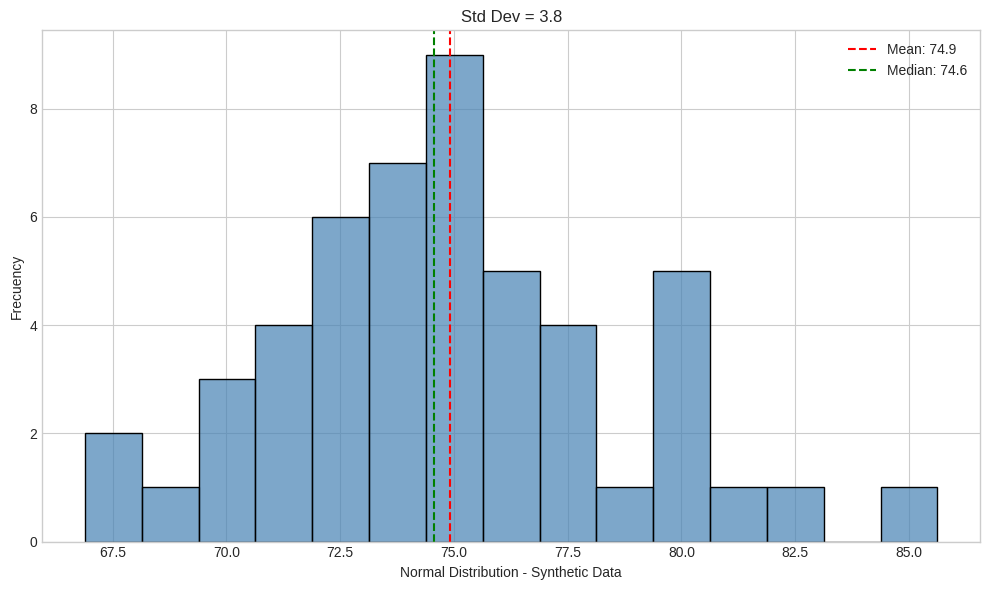

In [ ]:
# 🌟 Exercise 2 : Statistical Analysis
# calculate statistical measures for a dataset: Using NumPy, generate an array of 50 random numbers and compute: The mean and median; The standard deviation.

np.random.seed(42)
array = np.random.normal(loc=75, scale=4, size=50)

mean_val = np.mean(array )
median_val = np.median(array)
std_val = np.std(array)

print(f"Mean: {mean_val:.1f}, Median: {median_val:.1f}, Std Dev: {std_val:.1f}")

sns.histplot(array, bins=15, edgecolor='black', alpha=0.7, color='steelblue')

plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {array.mean():.1f}')
plt.axvline(median_val, color='green', linestyle='--', label=f'Median: {np.median(array):.1f}')

plt.title(f'Std Dev = {std_val:.1f}')
plt.xlabel('Normal Distribution - Synthetic Data')
plt.ylabel('Frecuency')

plt.legend()
plt.tight_layout()
plt.show()

The generated sintetic dataset has a mean, median, and standard deviation consistent with the defined normal distribution. The histogram visualizes the distribution and highlights the central tendency.

In [ ]:
# 🌟 Exercise 3 : Date Manipulation
# Create a NumPy array of dates for the month of January 2023.

np.random.seed(42)

january_2023 = np.arange('2023-01-01', '2023-02-01', dtype='datetime64[D]')
print(f"All days in January 2023 ({len(january_2023)} days):")
print(january_2023)

# Convert these dates to another format (e.g., YYYY/MM/DD).

# Convert dates to strings
january_strings = january_2023.astype(str)  # convert to strings  '2023-01-01'
print()

# Convert to YYYY/MM/DD format
formatted = np.char.replace(january_strings, '-', '/')  # replace '-' with '/'
print("Converted format (YYYY/MM/DD):")
print(formatted)


All days in January 2023 (31 days):
['2023-01-01' '2023-01-02' '2023-01-03' '2023-01-04' '2023-01-05'
 '2023-01-06' '2023-01-07' '2023-01-08' '2023-01-09' '2023-01-10'
 '2023-01-11' '2023-01-12' '2023-01-13' '2023-01-14' '2023-01-15'
 '2023-01-16' '2023-01-17' '2023-01-18' '2023-01-19' '2023-01-20'
 '2023-01-21' '2023-01-22' '2023-01-23' '2023-01-24' '2023-01-25'
 '2023-01-26' '2023-01-27' '2023-01-28' '2023-01-29' '2023-01-30'
 '2023-01-31']

Converted format (YYYY/MM/DD):
['2023/01/01' '2023/01/02' '2023/01/03' '2023/01/04' '2023/01/05'
 '2023/01/06' '2023/01/07' '2023/01/08' '2023/01/09' '2023/01/10'
 '2023/01/11' '2023/01/12' '2023/01/13' '2023/01/14' '2023/01/15'
 '2023/01/16' '2023/01/17' '2023/01/18' '2023/01/19' '2023/01/20'
 '2023/01/21' '2023/01/22' '2023/01/23' '2023/01/24' '2023/01/25'
 '2023/01/26' '2023/01/27' '2023/01/28' '2023/01/29' '2023/01/30'
 '2023/01/31']


Successfully created a range of dates for January 2023 and converted them into a new format (YYYY/MM/DD), demonstrating NumPy’s ability to handle and format date data efficiently.

In [ ]:
# 🌟 Exercise 4 : Data Manipulation with NumPy and Pandas
# Create a DataFrame with random numbers and perform:
#     Conditional selection of data.
#     Aggregation functions like sum and average.

# Generate random data
np.random.seed(42)
data = np.random.randint(10, 100, (20, 4))

# Create DataFrame
df = pd.DataFrame(data, columns=['Sales', 'Profit', 'Customers', 'Stores'])
print(df.head(5))
print(f"Type: {type(df)}")
print(f"Shape: {df.shape}")
print()

# Extract numeric columns as a NumPy array
numeric_data = df.iloc[:, :4]  # hint: .iloc[:, :4].values
print(f"As NumPy array:")
print(f"Type: {type(numeric_data)}")
print(f"Shape: {numeric_data.shape}")
print(f"First 5 rows:\n{numeric_data[:5]}")
print()

high_sales = df[df['Sales'] >= 80]
print("high_sales: when Sales >= 80")
print(high_sales)
print()

print("Variables average:")
print(df.mean())


   Sales  Profit  Customers  Stores
0     61      24         81      70
1     30      92         96      84
2     84      97         33      12
3     31      62         11      97
4     39      47         11      73
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (20, 4)

As NumPy array:
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (20, 4)
First 5 rows:
   Sales  Profit  Customers  Stores
0     61      24         81      70
1     30      92         96      84
2     84      97         33      12
3     31      62         11      97
4     39      47         11      73

high_sales: when Sales >= 80
    Sales  Profit  Customers  Stores
2      84      97         33      12
11     82      48         27      13
12     98      69         23      18
13     99      62         11      93

Variables average:
Sales        56.75
Profit       58.00
Customers    49.45
Stores       55.40
dtype: float64


The DataFrame allows conditional selection and aggregation of data. High-sales entries were correctly identified, and means provide a clear overview of the dataset.

[[  0  50 100 150 200]
 [ 30  80 130 180 230]
 [ 60 110 160 210 255]
 [ 30  80 130 180 230]
 [  0  50 100 150 200]]


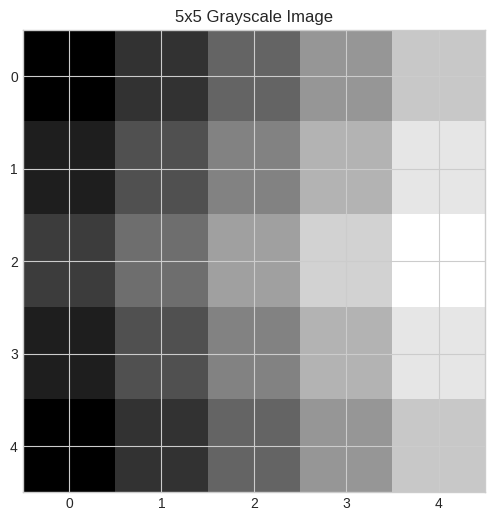

In [ ]:
# 🌟 Exercise 5 : Image Representation
# Explain how images are represented in NumPy arrays and demonstrate with a simple example (e.g., creating a 5x5 grayscale image).

# Grayscale Image
# * Represented as a 2D array (r,c) where r is the number of rows and c is the number of columns.
# * Each number represents the pixel's intensity.
# * Ranges from 0 to 255.
    # 0 = black
    # 255 = white
    # Intermediate values ​​= different shades of gray

# Color Image (RGB)
# Represented as a 3D array.
# Dimensions:  # height (rows) × width (columns) × channels.
# The 3 channels are:
  # Red
  # Green
  # Blue
# Each pixel has 3 numbers.

#  5x5 grayscale image
image = np.array([
    [0, 50, 100, 150, 200],
    [30, 80, 130, 180, 230],
    [60, 110, 160, 210, 255],
    [30, 80, 130, 180, 230],
    [0, 50, 100, 150, 200]
])

print(image)

# Display the image
plt.imshow(image, cmap='gray')
plt.title("5x5 Grayscale Image")
plt.show()


Grayscale and RGB images can be represented as 2D and 3D NumPy arrays, respectively. This exercise shows how pixel intensity is stored and visualized using arrays.

Training Program Data (30 employees):
Before: mean = 78.12, std = 8.85
After:  mean = 80.88, std = 9.21
Diff:   mean = 2.76, std = 1.83

Hypothesis Test Results:
  Test statistic (t): 8.1110
  p-value:            0.000000

  p-value (0.000000) < alpha (0.05)
  REJECT H0: The training program significantly improved productivity!



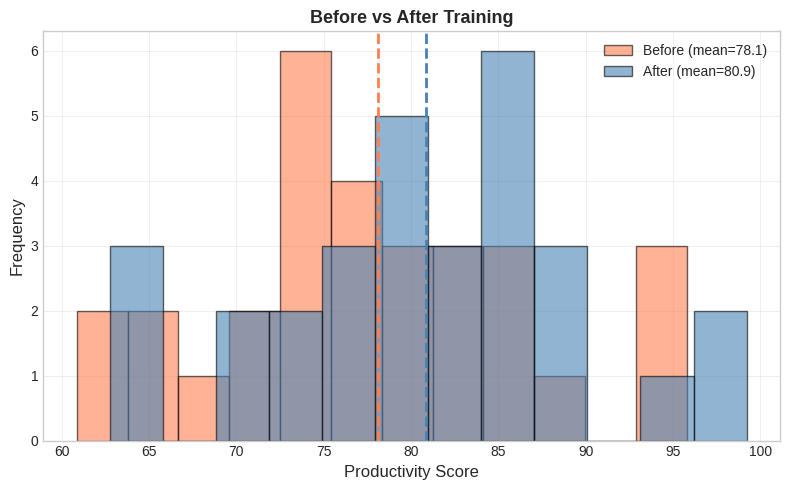

In [ ]:
# 🌟 Exercise 6 : Basic Hypothesis Testing
# Create a sample dataset to test the effectiveness of a new training program on employee productivity:

# Question: Did employees improve productivity thanks to the training provided?

np.random.seed(42)

# Productivity scores before training (mean ~80, std ~10)
productivity_before = np.random.normal(loc=80, scale=10, size=30)

# After training: same employees, but with some improvement  (SAMPLE NOT INDEPENDENT)
productivity_after = productivity_before + np.random.normal(loc=3, scale=2, size=30)

# The differences
differences = productivity_after - productivity_before

print("Training Program Data (30 employees):")
print(f"Before: mean = {productivity_before.mean():.2f}, std = {productivity_before.std():.2f}")
print(f"After:  mean = {productivity_after.mean():.2f}, std = {productivity_after.std():.2f}")
print(f"Diff:   mean = {differences.mean():.2f}, std = {differences.std():.2f}")
print()

# Paired t-test: are the differences significantly different from 0?
# H0: mean difference = 0 (training had no effect)
# H1: mean difference > 0 (training improved productivity)

t_stat, p_value = stats.ttest_1samp(differences, 0)  # one-sample t-test on differences, testing against 0

print("Hypothesis Test Results:")
print(f"  Test statistic (t): {t_stat:.4f}")
print(f"  p-value:            {p_value:.6f}")
print()

alpha = 0.05
if p_value < alpha:
    print(f"  p-value ({p_value:.6f}) < alpha ({alpha})")
    print("  REJECT H0: The training program significantly improved productivity!")
else:
    print(f"  p-value ({p_value:.6f}) >= alpha ({alpha})")
    print("  FAIL TO REJECT H0: Not enough evidence that training had an effect.")
print()

# Visualize: before vs after

plt.figure(figsize=(8,5))

# Overlapping histogram
plt.hist(productivity_before, bins=12, alpha=0.6, color='coral',
         edgecolor='black', label=f'Before (mean={productivity_before.mean():.1f})')
plt.hist(productivity_after, bins=12, alpha=0.6, color='steelblue',
         edgecolor='black', label=f'After (mean={productivity_after.mean():.1f})')

# Media lines
plt.axvline(productivity_before.mean(), color='coral', linewidth=2, linestyle='--')
plt.axvline(productivity_after.mean(), color='steelblue', linewidth=2, linestyle='--')

plt.xlabel('Productivity Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Before vs After Training', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The paired t-test shows that the training program significantly improved employee productivity, as the p-value is less than 0.05. The histogram confirms the shift in scores before and after training.

In [ ]:
# 🌟 Exercise 7 : Complex Array Comparison
# Create two arrays and perform element-wise comparison to find which elements are greater in the first array.

# Array Comparison between 2 stores and its revenue
np.random.seed(42)
store_1 = np.random.randint(1, 200, 12)
store_2 = np.random.randint(1, 200, 12)

print(f"Revenue Store 1: {store_1}")
print(f"Revenue Store 2: {store_2}")

# Comparison
comparison = store_1 > store_2
wins = comparison.sum()
total = len(comparison)
percentage = comparison.mean()*100

print(f"\nRevenue in Store 1 > Store 2: {comparison}")
print(f"\nStore 1 had higher revenue in {wins} out of {total} months ({percentage:.1f}%)")


Revenue Store 1: [103 180  93  15 107  72 189  21 103 122  75  88]
Revenue Store 2: [117 100 104 152 131 150  53   2  88 158  38 130]

Revenue in Store 1 > Store 2: [False  True False False False False  True  True  True False  True False]

Store 1 had higher revenue in 5 out of 12 months (41.7%)


Element-wise comparison reveals which store had higher revenue each month. Store 1 outperformed Store 2 in 41,7% of the months, demonstrating NumPy’s efficiency for logical array operations.

In [ ]:
# 🌟 Exercise 8 : Time Series Data Manipulation
# Generate time series data for the year 2023. Demonstrate slicing for the following intervals:
# January to March
# April to June
# July to September
# October to December

# Generate a time series data for a specific period and demonstrate how to slice this data for different intervals.

# Generate a year of random data
np.random.seed(42)
dates = np.arange('2023-01-01', '2024-01-01', dtype='datetime64[D]')
values = np.random.randint(60, 100, len(dates))

#check
print(dates[:5])
print(values[:5])

# Define quarter boundaries
quarters = [
    ("Q1: Jan-Mar", '2023-01-01', '2023-04-01'),
    ("Q2: Apr-Jun", '2023-04-01', '2023-07-01'),
    ("Q3: Jul-Sep", '2023-07-01', '2023-10-01'),
    ("Q4: Oct-Dec", '2023-10-01', '2024-01-01'),
]

print("Quarterly Analysis:")
for name, start, end in quarters:
    mask = (dates >= np.datetime64(start)) & (dates < np.datetime64(end))  # boolean mask: dates >= start AND dates < end
    q_values = values[mask]
    print(f"  {name}: Mean=${q_values.mean():.2f}, "
          f"Min=${q_values.min():.2f}, Max=${q_values.max():.2f}")


['2023-01-01' '2023-01-02' '2023-01-03' '2023-01-04' '2023-01-05']
[98 88 74 67 80]
Quarterly Analysis:
  Q1: Jan-Mar: Mean=$78.68, Min=$60.00, Max=$99.00
  Q2: Apr-Jun: Mean=$80.95, Min=$60.00, Max=$99.00
  Q3: Jul-Sep: Mean=$79.54, Min=$60.00, Max=$99.00
  Q4: Oct-Dec: Mean=$82.18, Min=$60.00, Max=$99.00


It was generated a year of daily data and demonstrated how to slice it by quarters. The mean, min, and max for each quarter provide a simple overview of trends throughout the year.

In [ ]:
# 🌟 Exercise 9 : Data Conversion
# Demonstrate how to convert a NumPy array to a Pandas DataFrame and vice versa.

# Generate synthetic students data (NumPy arrays)
np.random.seed(42)
n_students = 30
ages = np.random.randint(18, 40, n_students)
score_maths = np.clip(np.random.normal(70, 10, n_students), 0, 100)
score_english = np.clip(np.random.normal(75, 12, n_students), 0, 100)
score_coding = np.clip(np.random.normal(72, 11, n_students), 0, 100)

 #np.clip to avoid score < 0  or > 100

# Convert NumPy → Pandas
df = pd.DataFrame({
    "Age": ages,
    "Math": score_maths.round(1),
    "English": score_english.round(1),
    "Coding": score_coding.round(1)
})
print("\nConverted to DataFrame:")
print(df.head(5))
print(f"\nShape: {df.shape}")
print(type(df))

# Convert Pandas → NumPy
back_to_array = df.to_numpy()
print("\nBack to NumPy array:")
print(back_to_array[:5])
print(type(back_to_array))

# Conditional selection
top_students = df[
    (df['Math'] >= 75) &
    (df['English'] >= 75) &
    (df['Coding'] >= 75)
]
print("\nTop students:")
print(top_students)
print()

# Aggregation
print(f"  Average age:         {df['Age'].mean():.1f} years")
print(f"  Average Math Score:  {df['Math'].mean():,.1f}")
print(f"  Average English Score:  {df['English'].mean():,.1f}")
print(f"  Average Coding Score:  {df['Coding'].mean():,.1f}")

df['avg_score'] = df[['Math','English','Coding']].mean(axis=1).round(1)
mean_general = df['avg_score'].mean().round(1)
print(f"  General Mean Score: {mean_general:.1f}")
print()

above_mean = df[df['avg_score'] > mean_general]
print(f"Rows where avg_score > General Mean Score: {len(above_mean)} out of {len(df)}")
print(above_mean.head())



Converted to DataFrame:
   Age  Math  English  Coding
0   24  55.2     81.8    63.4
1   37  84.9     75.3    62.7
2   32  69.8     80.7    70.3
3   28  73.6     82.9    61.4
4   25  74.2    100.0    73.7

Shape: (30, 4)
<class 'pandas.core.frame.DataFrame'>

Back to NumPy array:
[[ 24.   55.2  81.8  63.4]
 [ 37.   84.9  75.3  62.7]
 [ 32.   69.8  80.7  70.3]
 [ 28.   73.6  82.9  61.4]
 [ 25.   74.2 100.   73.7]]
<class 'numpy.ndarray'>

Top students:
    Age  Math  English  Coding
14   39  79.5     80.7    75.2
15   38  85.8     90.6    81.9

  Average age:         29.4 years
  Average Math Score:  69.2
  Average English Score:  76.9
  Average Coding Score:  72.3
  General Mean Score: 72.8

Rows where avg_score > General Mean Score: 15 out of 30
   Age  Math  English  Coding  avg_score
1   37  84.9     75.3    62.7       74.3
2   32  69.8     80.7    70.3       73.6
4   25  74.2    100.0    73.7       82.6
5   38  78.3     87.9    70.8       79.0
6   24  67.1     76.2   100.0       81

NumPy arrays can be converted to Pandas DataFrames and vice versa. Conditional selection and aggregation demonstrate how DataFrames facilitate complex data analysis.

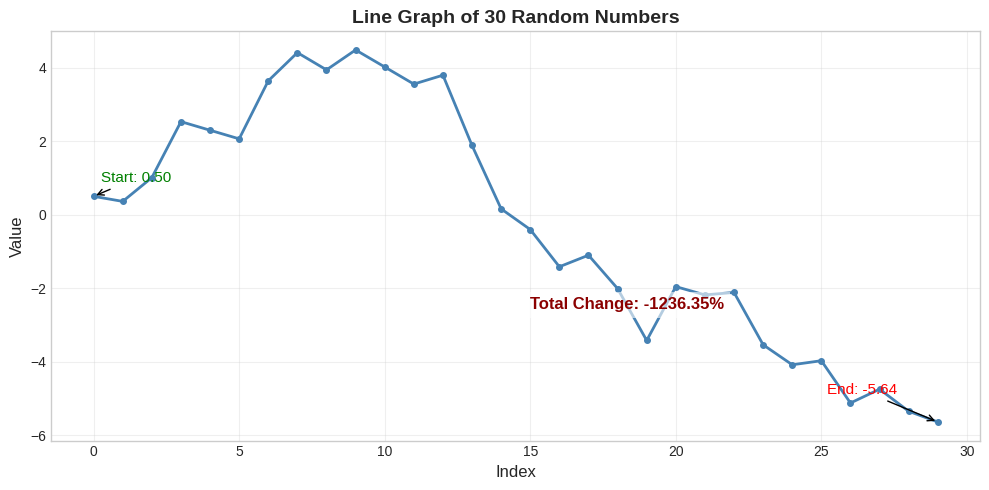

In [ ]:
# 🌟 Exercise 10 : Basic Visualization
# Use Matplotlib to visualize a simple dataset created with NumPy (e.g., a line graph of random numbers).

np.random.seed(42)
random_data = np.cumsum(np.random.normal(loc=0, scale=1, size=30)) # 30 random numbers (hint: np.cumsum of np.random.normal)

start_val = random_data[0]
end_val = random_data[-1]
total_change_pct = (end_val / start_val - 1) * 100

plt.figure(figsize=(10, 5))
plt.plot(range(30), random_data, linewidth=2, color='steelblue', marker='o', markersize=4)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title('Line Graph of 30 Random Numbers', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Anotación del valor inicial
plt.annotate(f'Start: {start_val:.2f}',
             xy=(0, start_val), xycoords='data',
             xytext=(5, 10), textcoords='offset points',
             arrowprops=dict(facecolor='green', arrowstyle='->'),
             fontsize=11, color='green')

# Anotación del valor final
plt.annotate(f'End: {end_val:.2f}',
             xy=(29, end_val), xycoords='data',
             xytext=(-80, 20), textcoords='offset points',
             arrowprops=dict(facecolor='red', arrowstyle='->'),
             fontsize=11, color='red')

plt.text(15, (start_val + end_val)/2, f'Total Change: {total_change_pct:.2f}%',
         fontsize=12, color='darkred', fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.tight_layout()
plt.show()





The cumulative sum of random numbers shows a simple trend over time. Line plots with markers effectively visualize sequential data, demonstrating basic time-series plotting in Matplotlib.